In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:

csv_path = '../data/Processed/tea_preprocessed.csv'
if csv_path is None:
    raise FileNotFoundError('Could not find 01_sales_index.csv in expected locations.')

df = pd.read_csv(csv_path)
print(f'Loaded file: {csv_path}')

Loaded file: ../data/Processed/tea_preprocessed.csv


In [4]:
df.head()


,sale_id,sale_number,sale_year,sale_month,sale_date_raw,table_source,elevation,category_type,grade,tier,...,all_regions__avg_precipitation,is_production_known,price_mid_usd,sale_month_enc,tier_enc,elevation_enc,category_type_enc,table_source_enc,price_mid_lkr_log,has_price_target
0,SALE_34_2025,34,2025.0,September,01ST/02ND September 2025,04_high_grown,high_grown,high_grown,bop,NaN,...,39.85,0,4.156889,9.0,0,3,1,0,7.123673,1
1,SALE_34_2025,34,2025.0,September,01ST/02ND September 2025,04_high_grown,high_grown,high_grown,bopf,NaN,...,39.85,0,4.324506,9.0,0,3,1,0,7.163172,1
2,SALE_34_2025,34,2025.0,September,01ST/02ND September 2025,04_high_grown,high_grown,high_grown,pekoe_fbop,NaN,...,39.85,0,4.089842,9.0,0,3,1,0,7.107425,1
3,SALE_34_2025,34,2025.0,September,01ST/02ND September 2025,04_high_grown,high_grown,high_grown,op,NaN,...,39.85,0,3.452900,9.0,0,3,1,0,6.938284,1
4,SALE_34_2025,34,2025.0,September,01ST/02ND September 2025,04_high_grown,high_grown,high_grown,bop,NaN,...,39.85,0,4.391552,9.0,0,3,1,0,7.178545,1


In [5]:
df.columns.tolist()

['sale_id',
 'sale_number',
 'sale_year',
 'sale_month',
 'sale_date_raw',
 'table_source',
 'elevation',
 'category_type',
 'grade',
 'tier',
 'category',
 'price_lo_lkr',
 'price_hi_lkr',
 'price_mid_lkr',
 'price_range_lkr',
 'total_lots',
 'total_kgs',
 'reprint_lots',
 'reprint_quantity',
 'sentiment_overall',
 'sentiment_ex_estate',
 'sentiment_low_grown',
 'western_nuwara_eliya_weather_score',
 'uva_udapussellawa_weather_score',
 'low_grown_weather_score',
 'avg_weather_severity',
 'crop_nuwara_eliya_trend',
 'crop_western_trend',
 'crop_uva_trend',
 'crop_low_grown_trend',
 'sl_production_mkgs',
 'fx_usd_2026',
 'fx_usd_2025',
 'fx_gbp_2026',
 'fx_gbp_2025',
 'fx_eur_2026',
 'fx_eur_2025',
 'fx_jpy_2026',
 'fx_jpy_2025',
 'private_sales_weekly_2026',
 'private_sales_weekly_2025',
 'private_sales_todate_2026',
 'private_sales_todate_2025',
 'public_auction_weekly_2026',
 'public_auction_weekly_2025',
 'public_auction_todate_2026',
 'public_auction_todate_2025',
 'forward_contrac

In [74]:

missing_count = df['gross_lkr_weekly_total_2026'].isna().sum()
print(f"Missing values in gross_lkr_weekly_total_2026: {missing_count}")

Missing values in gross_lkr_weekly_total_2026: 7


In [75]:
plot_columns = ['sale_number', 'gross_lkr_weekly_total_2026']
if 'sale_date_raw' in df.columns:
    plot_columns.insert(1, 'sale_date_raw')

plot_df = df[plot_columns].copy()

plot_df['gross_lkr_weekly_total_2026'] = pd.to_numeric(
    plot_df['gross_lkr_weekly_total_2026'], errors='coerce'
)

plot_df['sale_number'] = pd.to_numeric(plot_df['sale_number'], errors='coerce')
plot_df = plot_df.dropna(subset=['sale_number', 'gross_lkr_weekly_total_2026'])

plot_df['sale_number'] = plot_df['sale_number'].astype(int)
plot_df = plot_df.sort_values('sale_number').reset_index(drop=True)

print('Clean plotting dataframe preview:')
display(plot_df.head())
print(f'Rows ready for plotting: {len(plot_df)}')

Clean plotting dataframe preview:


,sale_number,sale_date_raw,gross_lkr_weekly_total_2026
0,1,06TH/07TH January 2026,1207.29
1,5,02ND/03RD February 2026,1173.31
2,9,03RD/04TH March 2026,1177.54


Rows ready for plotting: 3


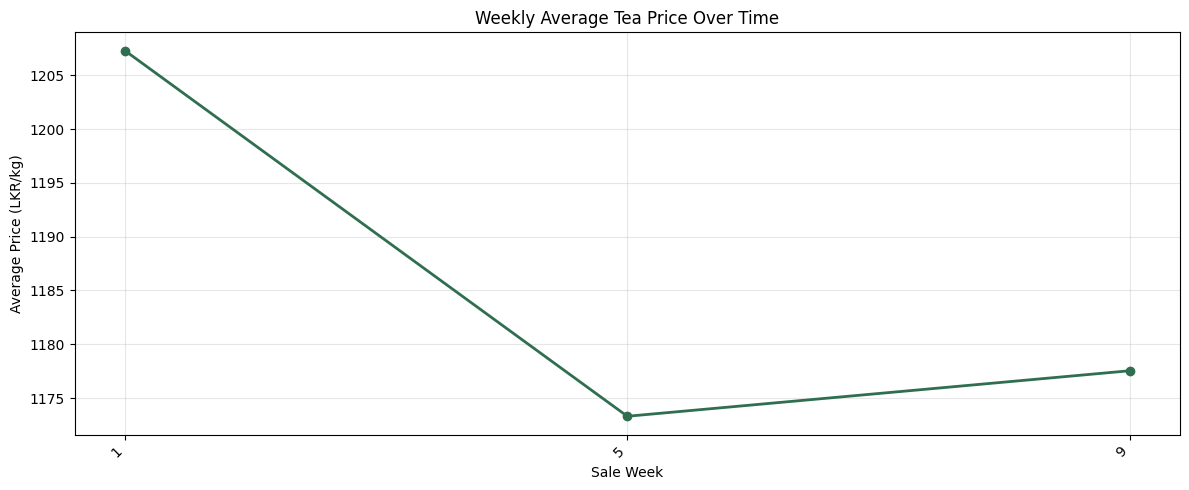

In [76]:
plt.figure(figsize=(12, 5))
plt.plot(
    plot_df['sale_number'],
    plot_df['gross_lkr_weekly_total_2026'],
    marker='o',
    linewidth=2,
    color='#2f6f4f',
)

plt.title('Weekly Average Tea Price Over Time')
plt.xlabel('Sale Week')
plt.ylabel('Average Price (LKR/kg)')
plt.grid(True, alpha=0.3)
plt.xticks(plot_df['sale_number'], rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4) Heatmap: Weekly Weather Condition by Region

This view converts textual weather comments into category labels (`bright`, `sunny`, `rain`, `showers`, `mist`, `dry`) and plots them across weeks.

- Rows: merged tea regions (`Western / Nuwara Eliya`, `Uva / Udapussellawa`, `Low Growns`)
- Columns: sale weeks
- Colors: weather category
- Cell annotation: weather category + crop-intake direction arrow (`↑` increase, `↓` decrease, `→` steady, `?` unknown)

In [77]:
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

weather_path = Path('../tea_output/09_weather_features.csv')
weather_df = pd.read_csv(weather_path)

In [78]:
def normalize_region(label: str) -> str:
    txt = str(label).lower()
    if 'low grown' in txt:
        return 'Low Growns'
    if 'uva' in txt or 'uda pussellawa' in txt or 'udapussellawa' in txt:
        return 'Uva / Udapussellawa'
    if 'western high grown' in txt or 'nuwara' in txt:
        return 'Western / Nuwara Eliya'
    return str(label)


def classify_weather(row) -> str:
    keywords = str(row.get('text_keywords', '')).lower()
    summary = str(row.get('text_raw_summary', '')).lower()
    text = f"{keywords}|{summary}"

    if 'thunder' in text or 'rain' in text:
        return 'rain'
    if 'shower' in text:
        return 'showers'
    if 'mist' in text or 'misty' in text:
        return 'mist'
    if 'sunny' in text or 'sunshine' in text:
        return 'sunny'
    if 'bright' in text:
        return 'bright'
    if 'dry' in text:
        return 'dry'
    return 'unknown'


def mode_or_unknown(series: pd.Series) -> str:
    s = series.dropna().astype(str)
    if s.empty:
        return 'unknown'
    return s.value_counts().index[0]



C:\Users\thilo\AppData\Local\Temp\ipykernel_12960\3564868363.py:49: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heat_values = weather_pivot.fillna('unknown').replace(category_to_code)


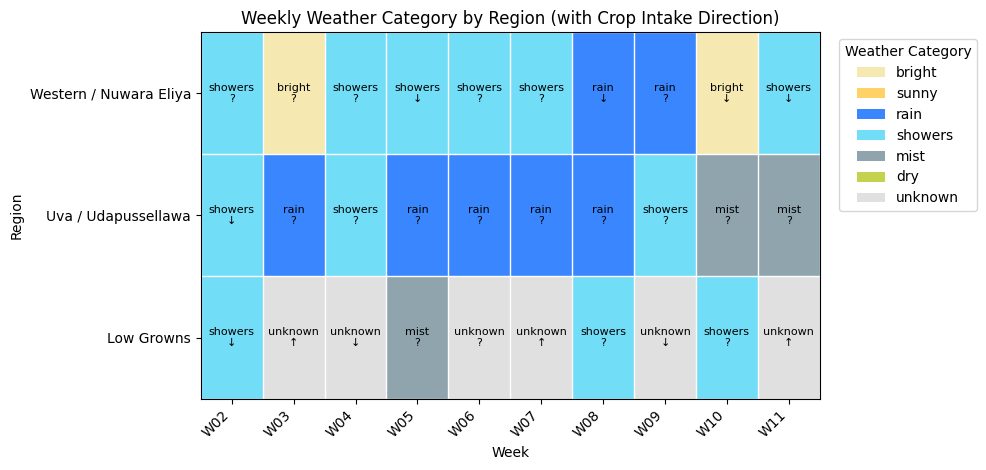

In [79]:

required_cols = ['auction_date', 'region_label', 'text_keywords', 'text_raw_summary', 'text_crop_change']
missing_cols = [c for c in required_cols if c not in weather_df.columns]
if missing_cols:
    raise KeyError(f'Missing required columns in 09_weather_features.csv: {missing_cols}')

weather_df['auction_date'] = pd.to_datetime(weather_df['auction_date'], errors='coerce')
weather_df = weather_df.dropna(subset=['auction_date', 'region_label']).copy()


weather_df['region_group'] = weather_df['region_label'].apply(normalize_region)
weather_df['weather_category'] = weather_df.apply(classify_weather, axis=1)
weather_df['iso_week'] = weather_df['auction_date'].dt.isocalendar().week.astype(int)
weather_df['week_label'] = weather_df['iso_week'].apply(lambda w: f'W{w:02d}')

region_order = ['Western / Nuwara Eliya', 'Uva / Udapussellawa', 'Low Growns']
week_order = (
    weather_df[['iso_week', 'week_label']]
    .drop_duplicates()
    .sort_values('iso_week')['week_label']
    .tolist()
)

weather_pivot = (
    weather_df
    .pivot_table(
        index='region_group',
        columns='week_label',
        values='weather_category',
        aggfunc=mode_or_unknown,
    )
    .reindex(index=region_order)
    .reindex(columns=week_order)
)

crop_pivot = (
    weather_df
    .pivot_table(
        index='region_group',
        columns='week_label',
        values='text_crop_change',
        aggfunc=mode_or_unknown,
    )
    .reindex(index=region_order)
    .reindex(columns=week_order)
)

category_order = ['bright', 'sunny', 'rain', 'showers', 'mist', 'dry', 'unknown']
category_to_code = {cat: i for i, cat in enumerate(category_order)}
heat_values = weather_pivot.fillna('unknown').replace(category_to_code)

arrow_map = {
    'increase': '↑',
    'decrease': '↓',
    'steady': '→',
    'unchanged': '→',
    'same': '→',
    'unknown': '?',
}

def crop_arrow(v: str) -> str:
    txt = str(v).strip().lower()
    return arrow_map.get(txt, '?')

colors = ['#f6e8b1', '#ffd166', '#3a86ff', '#72ddf7', '#90a4ae', '#c3d350', '#e0e0e0']
cmap = ListedColormap(colors)

fig, ax = plt.subplots(figsize=(max(10, 0.65 * len(week_order)), 4.8))
im = ax.imshow(heat_values.values, aspect='auto', cmap=cmap, vmin=0, vmax=len(category_order) - 1)

ax.set_xticks(np.arange(len(week_order)))
ax.set_xticklabels(week_order, rotation=45, ha='right')
ax.set_yticks(np.arange(len(region_order)))
ax.set_yticklabels(region_order)
ax.set_title('Weekly Weather Category by Region (with Crop Intake Direction)')
ax.set_xlabel('Week')
ax.set_ylabel('Region')

for i, region in enumerate(region_order):
    for j, week in enumerate(week_order):
        cat = str(weather_pivot.loc[region, week])
        crop = crop_arrow(crop_pivot.loc[region, week])
        label = f"{cat}\n{crop}"
        ax.text(j, i, label, ha='center', va='center', fontsize=8, color='black')

ax.set_xticks(np.arange(-0.5, len(week_order), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(region_order), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=1.0)
ax.tick_params(which='minor', bottom=False, left=False)

legend_handles = [Patch(facecolor=colors[i], edgecolor='none', label=category_order[i]) for i in range(len(category_order))]
ax.legend(handles=legend_handles, title='Weather Category', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()